### **Mount to the Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2'

%cd $base_dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2


In [ ]:
# Run the command below if you need
!pip install -q -r requirements/SIFT.txt

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from src.geometry import calculate_fundamental_matrix
from src.feature_extraction import extract_sift_features, knn_matcher
from src.visualization import stereo_viewer, show_matching, draw_epilines

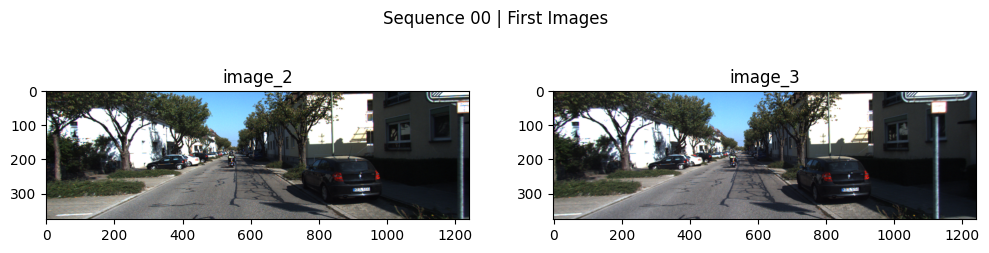

In [ ]:
left_path = f'{base_dir}/data/kitti_sample/sequences/00/image_2/000000.png'
right_path = f'{base_dir}/data/kitti_sample/sequences/00/image_3/000000.png'

left_img = cv.imread(left_path)
right_img = cv.imread(right_path)

stereo_viewer(left_img, right_img)

# **SIFT DESCRIPTORS**

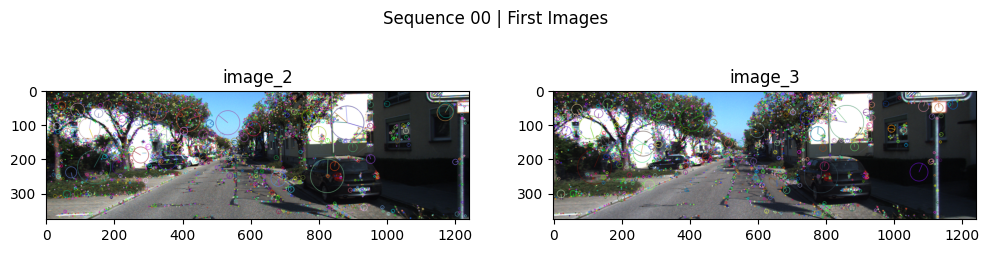

In [ ]:
left_kps, left_des = extract_sift_features(left_img)
right_kps, right_des = extract_sift_features(right_img)

left_drawn_kps = cv.drawKeypoints(left_img, left_kps, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
right_drawn_kps = cv.drawKeypoints(right_img, right_kps, None, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

stereo_viewer(left_drawn_kps, right_drawn_kps)

# **Feature Matcher**

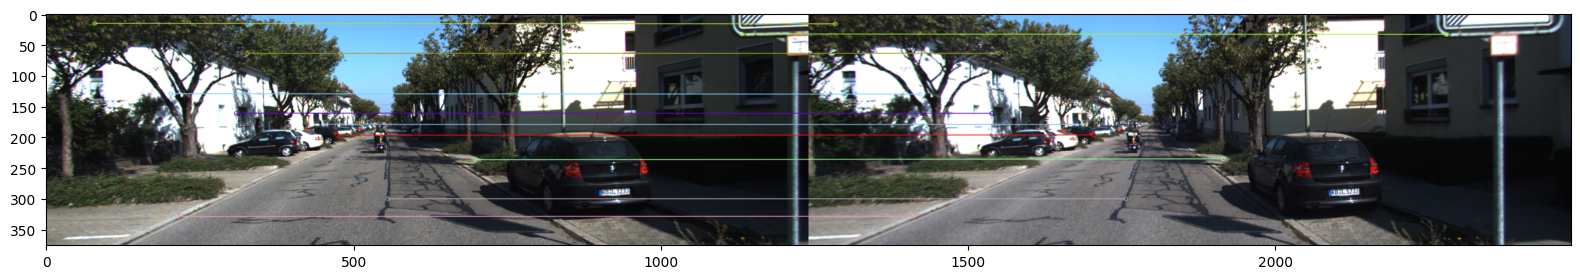

In [ ]:
good = knn_matcher(left_des, right_des)
show_matching((left_img, right_img), (left_kps, right_kps), good, 10)

# **Fundamental Matrix Calculation**

In [ ]:
F, left_matched_pts, right_matched_pts = calculate_fundamental_matrix(good, (left_kps, right_kps))

# **Computing Epipolar Lines**

In [ ]:
lines_1 = cv.computeCorrespondEpilines(right_matched_pts, 2, F)
lines_2 = cv.computeCorrespondEpilines(left_matched_pts, 1, F)

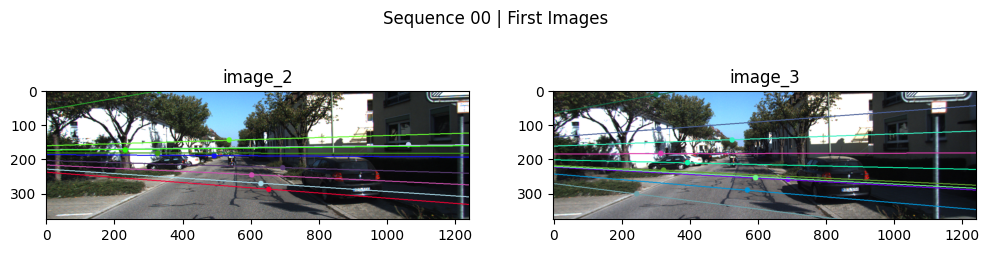

In [ ]:
left_img_with_lines = draw_epilines(left_img.copy(), lines_1, left_matched_pts)
right_img_with_lines = draw_epilines(right_img.copy(), lines_2, right_matched_pts)

stereo_viewer(left_img_with_lines, right_img_with_lines)